In [1]:
# Install required packages
import os
os.environ["PATH"] += r";C:\Program Files\Git\cmd"

%pip install -q git+https://github.com/alemartinello/dstapi
%pip install -q fredapi

# Import required packages

import numpy as np
import pandas as pd

#API
from dstapi import DstApi


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# 1. Inequality in Denmark

## 1.1 The Gini Coefficient and the top 10 percent share

We will now import data from Statistics Denmark, specifically table IFOR41 and IFOR32, to look at the inequality in Denmark over time.


In [2]:
IFOR41=DstApi('IFOR41')
IFOR32=DstApi('IFOR32')

# Quick overview of the dataset
IFOR41.tablesummary(language='en')




Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


We want a dataset with Year and Gini coefficient in All Denmark, so we have to trim our dataset

In [3]:
IFOR41.variable_levels('ULLIG',language='en')

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [4]:
params={
    'table': 'IFOR41',
    'format': 'BULK',
    'lang':'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code':'TID', 'values': ['*']},
        {'code':'KOMMUNEDK', 'values': ['000']},       
    ]
}

Gini=IFOR41.get_data(params=params)

display(Gini.head(10)
        )


,ULLIG,TID,KOMMUNEDK,INDHOLD
0,Gini coefficient,2016,All Denmark,28.97
1,Gini coefficient,1999,All Denmark,23.83
2,Gini coefficient,1988,All Denmark,22.06
3,Gini coefficient,2015,All Denmark,28.77
4,Gini coefficient,1989,All Denmark,21.93
5,Gini coefficient,2008,All Denmark,27.94
6,Gini coefficient,1994,All Denmark,22.50
7,Gini coefficient,2021,All Denmark,30.28
8,Gini coefficient,2011,All Denmark,27.68
9,Gini coefficient,2009,All Denmark,26.74


In [5]:
Gini=Gini.iloc[:,[1,3]]
display(Gini.head(10))


,TID,INDHOLD
0,2016,28.97
1,1999,23.83
2,1988,22.06
3,2015,28.77
4,1989,21.93
5,2008,27.94
6,1994,22.50
7,2021,30.28
8,2011,27.68
9,2009,26.74


In [6]:
# We want to sort the time in ascending order, so we can see the development of the Gini coefficient over time.
Gini = Gini.sort_values('TID').reset_index(drop=True)
Gini=Gini.rename(columns={'INDHOLD':'Gini coefficient'})
display(Gini.head(5))


,TID,Gini coefficient
0,1987,22.07
1,1988,22.06
2,1989,21.93
3,1990,22.16
4,1991,21.99


### 1.1.1 Gini in DK over time
We now want the plot this change over time in the Gini Coefficient, but we have to convert the Gini coefficient to numeric, as it is currently a string

In [7]:
Gini['Gini coefficient'] = pd.to_numeric(Gini['Gini coefficient'], errors='coerce')

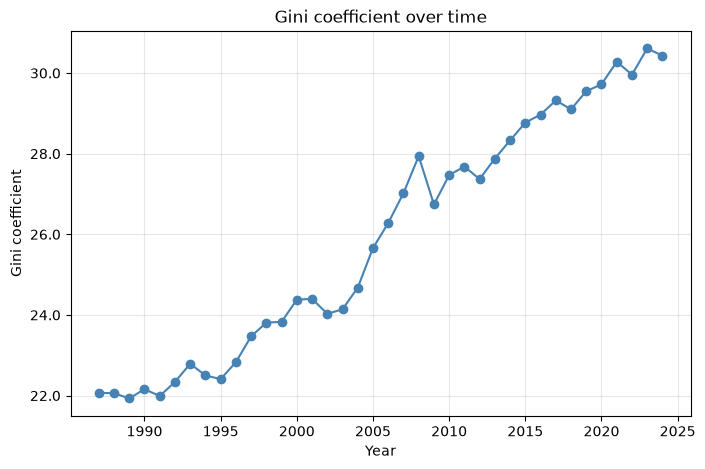

In [8]:
# Plotting the Gini coefficient over time
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Gini['TID'], Gini['Gini coefficient'], marker='o', linewidth=1.5, color='steelblue')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')
ax.set_title('Gini coefficient over time')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.grid(alpha=0.3)
plt.show()


### 1.1.2 Share of income to the top 10%
Now we compare this devolopment with the total share of income going to the richest 10%. We have to get the 1st decils income as a percentage of the totalt income. 


In [9]:
# Quick overview of the dataset
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [10]:
params={
    'table': 'IFOR32',
    'format': 'BULK',
    'lang':'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code':'TID', 'values': ['*']},
        {'code':'KOMMUNEDK', 'values': ['000']},       
    ]
}

Top10=IFOR32.get_data(params=params)
display(Top10.head(5))

,DECILGEN,TID,KOMMUNEDK,INDHOLD
0,First decil,2013,All Denmark,75704
1,Second decil,2013,All Denmark,140049
2,Third decil,2013,All Denmark,163582
3,Fourth decil,2013,All Denmark,185931
4,Fifth decil,2013,All Denmark,209384


In [11]:
# We convert the 'INDHOLD' and 'TID' columns to numeric types
Deciles = IFOR32.get_data(params=params)
Deciles['INDHOLD'] = pd.to_numeric(Deciles['INDHOLD'], errors='coerce')
Deciles['TID'] = pd.to_numeric(Deciles['TID'])

# We create total income by year by grouping the data by 'TID' and summing the 'INDHOLD' values
total_by_year = Deciles.groupby('TID')['INDHOLD'].sum().rename('Total income')

# We divide the 'INDHOLD' values of the first decile by the total income for each year to get the share of total income for the first decile
Top10 = Deciles[Deciles['DECILGEN'] == 'Tenth decil'].merge(total_by_year, on='TID')
Top10['Share of total income (%)'] = Top10['INDHOLD'] / Top10['Total income'] * 100
Top10['Share of total income (%)'] = Top10['Share of total income (%)'].round(2)

display(Top10.head(5))

,DECILGEN,TID,KOMMUNEDK,INDHOLD,Total income,Share of total income (%)
0,Tenth decil,2013,All Denmark,560961,2465939,22.75
1,Tenth decil,2015,All Denmark,607665,2591198,23.45
2,Tenth decil,1997,All Denmark,286696,1418420,20.21
3,Tenth decil,2000,All Denmark,329207,1581961,20.81
4,Tenth decil,1999,All Denmark,308395,1519674,20.29


In [12]:
Top10=Top10[['TID', 'Share of total income (%)']]
Top10 =Top10.sort_values('TID').reset_index(drop=True)
display(Top10.head(5))

,TID,Share of total income (%)
0,1987,18.45
1,1988,18.43
2,1989,18.50
3,1990,18.64
4,1991,18.67


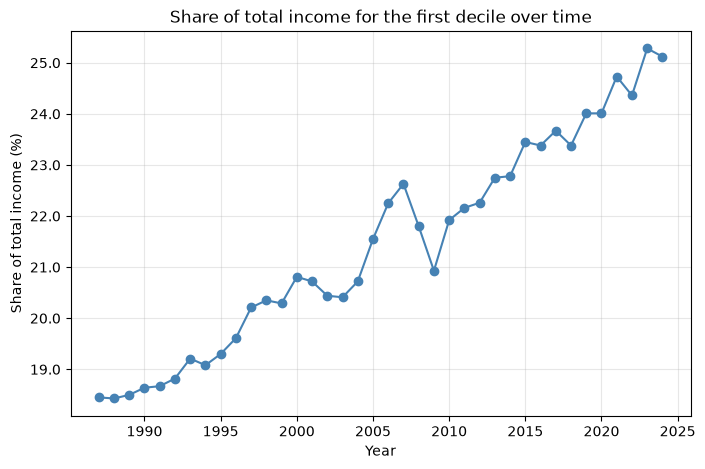

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Top10['TID'], Top10['Share of total income (%)'], marker='o', linewidth=1.5, color='steelblue')
ax.set_xlabel('Year')
ax.set_ylabel('Share of total income (%)')
ax.set_title('Share of total income for the first decile over time')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax.grid(alpha=0.3)
plt.show()

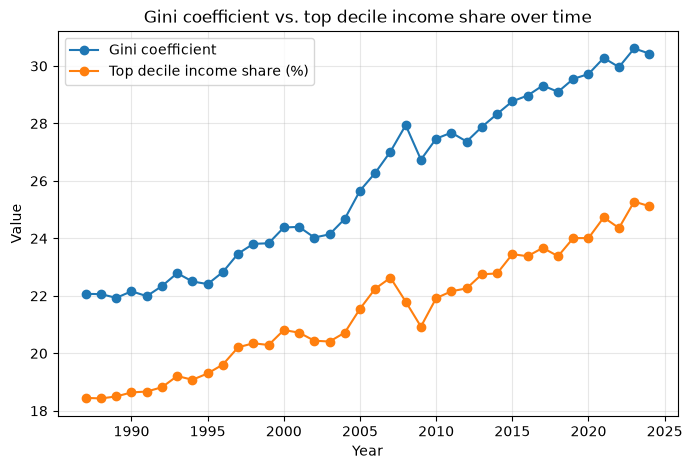

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(Gini['TID'], Gini['Gini coefficient'], marker='o', label='Gini coefficient')
ax.plot(Top10['TID'], Top10['Share of total income (%)'], marker='o', label='Top decile income share (%)')
ax.set_xlabel('Year')
ax.set_ylabel('Value')
ax.set_title('Gini coefficient vs. top decile income share over time')
ax.legend()
ax.grid(alpha=0.3)
plt.show()


### 1.1.3 Correlation between Ginis
We now want the correlation between these 2. 

In [15]:
# We want to find the correlation between the Gini coefficient and the share of total income for the first decile.
merged= pd.merge(Gini, Top10, on='TID')
correlation_df = merged['Gini coefficient'].corr(merged['Share of total income (%)'])
print(f"The correlation between the Gini coefficient and the share of total income for the first decile is: {correlation_df:.4f}")

The correlation between the Gini coefficient and the share of total income for the first decile is: 0.9816


### 1.1.4 Comparison of equality development
The inequality in Denmark has been steadily increasing since the 1990's, except for 2007 to 2009 where it was decreasing. The decrease is properly due to the financial crisis in 2007. The Gini coefficient and the top 10% income share follow eachothers trends pretty nicely, and have a correlation of 0.9816

## 1.2 Prediction

### 1.2.1 Minimizing with 'scipy.optimize.minimize'
We now want to predict the Gini coefficient in 2030 and 2040, by fitting a polynomial trend

In [16]:
# We define the function that we want to minimize.
def predict_one(beta,t_i,p):
    total=0
    for k in range(p+1):
        total += beta[k] * (t_i ** k)
    return total    
    
def predict_two(beta,t,y,p):
    total=0
    for i in range(len(t)):
        y_hat_I=predict_one(beta,t[i],p)
        total += (y[i] - y_hat_I) ** 2
    return total
from scipy.optimize import minimize
y=merged['Gini coefficient'].values
t=merged['TID'].values-1987
p=1
x0=[1,2]
result=minimize(predict_two,x0=x0,args=(t,y,p))
beta=result.x
t_2030=2030-1987
t_2040=2040-1987


gini_2030=predict_one(beta,t_2030,p)
gini_2040=predict_one(beta,t_2040,p)
print(f'Predicted Gini coefficient in 2030 is {gini_2030:.2f},\nand in 2040 is {gini_2040:.2f}')








Predicted Gini coefficient in 2030 is 32.38,
and in 2040 is 35.01


### 1.2.2 Verifiyng with 'np.polyfit'
We now check to see if we get the same result if we use np.polyfit

In [17]:
# We check if np.polyfit will give us the same result as our optimization method.
Polyfit_coeffs=np.polyfit(t,y,p)
gini_2030_np=np.polyval(Polyfit_coeffs,t_2030)
gini_2040_np=np.polyval(Polyfit_coeffs,t_2040)
print(f'Predicted Gini coefficient in 2030 using np.polyfit is {gini_2030_np:.2f},\nand in 2040 is {gini_2040_np:.2f}')


Predicted Gini coefficient in 2030 using np.polyfit is 32.38,
and in 2040 is 35.01


We see that our fitted polynomial and np.polyfit yields the exact same answer; 32.38 in 2030 and 35.01 in 2040

## 1.3 Municipalities

### 1.3.1 Gini *across* municipalities
We compute the correlation between top 10%'s income share and Gini coefficient across municipalities. To do this, we have to re-add the municipalities to our dataset, so we can compare the Gini coefficient and top 10% share across municipalities. We compare the municipalities in 2024.

In [18]:
# We add back all municipalities to IFOR41, and select 2024 as the comparison year.
from dstapi import DstApi
IFOR41=DstApi('IFOR41')

params={
    'table': 'IFOR41',
    'format': 'BULK',
    'lang':'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code':'TID', 'values': ['2024']},
        {'code':'KOMMUNEDK', 'values': ['*']},       
    ]
}

Gini_all=IFOR41.get_data(params=params)

display(Gini_all.head(5)
        )


,ULLIG,TID,KOMMUNEDK,INDHOLD
0,Gini coefficient,2024,All Denmark,30.43
1,Gini coefficient,2024,Copenhagen,34.97
2,Gini coefficient,2024,Frederiksberg,36.54
3,Gini coefficient,2024,Ballerup,26.72
4,Gini coefficient,2024,Brøndby,26.16


In [19]:
# We rename indhold to Gini coefficient, and sort the data by KOMMUNEDK.
Gini_all=Gini_all.rename(columns={'INDHOLD':'Gini coefficient'})

We do the same thing with IFOR32

In [20]:
IFOR32=DstApi('IFOR32')
params={
    'table': 'IFOR32',
    'format': 'BULK',
    'lang':'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code':'TID', 'values': ['2024']},
        {'code':'KOMMUNEDK', 'values': ['*']},       
    ]
}

Top10_all=IFOR32.get_data(params=params)
display(Top10_all.head(5))

,DECILGEN,TID,KOMMUNEDK,INDHOLD
0,Tenth decil,2024,All Denmark,852980
1,Tenth decil,2024,Copenhagen,908991
2,Tenth decil,2024,Frederiksberg,1178364
3,Tenth decil,2024,Ballerup,720642
4,Tenth decil,2024,Brøndby,594043


We can use the same code to find the 10th decil share of total income as we used earlier

In [21]:
# We convert the 'INDHOLD' columns to numeric types
import pandas as pd
Deciles = IFOR32.get_data(params=params)
Deciles['INDHOLD'] = pd.to_numeric(Deciles['INDHOLD'], errors='coerce')

# We create total income by year by grouping the data by 'KOMMUNEDK' and summing the 'INDHOLD' values
total_by_year = Deciles.groupby('KOMMUNEDK')['INDHOLD'].sum().rename('Total income')

# We divide the 'INDHOLD' values of the first decile by the total income for each year to get the share of total income for the first decile
Top10_all= Deciles[Deciles['DECILGEN'] == 'Tenth decil'].merge(total_by_year, on='KOMMUNEDK')
Top10_all['Share of total income (%)'] = Top10_all['INDHOLD'] / Top10_all['Total income'] * 100
Top10_all['Share of total income (%)'] = Top10_all['Share of total income (%)'].round(2)

display(Top10_all.head(5))

,DECILGEN,TID,KOMMUNEDK,INDHOLD,Total income,Share of total income (%)
0,Tenth decil,2024,All Denmark,852980,3395426,25.12
1,Tenth decil,2024,Copenhagen,908991,3409491,26.66
2,Tenth decil,2024,Frederiksberg,1178364,4046472,29.12
3,Tenth decil,2024,Ballerup,720642,3340838,21.57
4,Tenth decil,2024,Brøndby,594043,2896808,20.51


We now find the correlation between the sets, again reusing some code we used earlier

In [22]:
merged= pd.merge(Gini_all, Top10_all, on='KOMMUNEDK')
correlation_df = merged['Gini coefficient'].corr(merged['Share of total income (%)'])
print(f"The correlation between the Gini coefficient and the share of total income for the first decile is: {correlation_df:.4f}")

The correlation between the Gini coefficient and the share of total income for the first decile is: 0.9747


The correlation between the top 10%'s income share and the Gini coefficient is slightly weaker across municipalities (0.9747) in 2024 than over time on a national level (0.9816)

### 1.3.2 The 10 most and 10 least unequal municipalities

To answer this question, we will use the Gini coefficient as a measurement of inequality. 
We can do this by sorting by the Gini coefficient, and create a dataset with the first and last 10 observations

In [23]:
# We sort the dataset by the Gini coefficient in descending order to find the municipalities with the highest Gini coefficients.
merged_top=merged.sort_values('Gini coefficient', ascending=False).reset_index(drop=True)

# We want only what is displayed in the table, so we select the first 10 municipalities with the highest Gini coefficients.
merged_top=merged_top.head(10)

# We sort again but in reverse order to find the municipalities with the lowest Gini coefficients.
merged_bottom=merged.sort_values('Gini coefficient', ascending=True).reset_index(drop=True)

# We want only what is displayed in the table, so we select the first 10 municipalities with the lowest Gini coefficients.
merged_bottom=merged.sort_values('Gini coefficient', ascending=True).reset_index(drop=True).head(10)    
merged_bottom=merged_bottom.head(10)




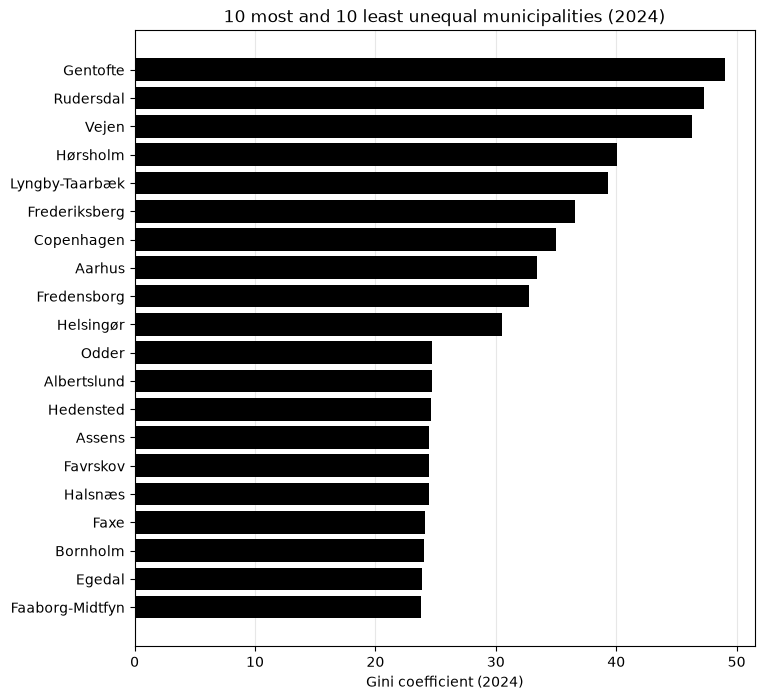

In [24]:
# We can now plot our data to visualize the 10 most and 10 least unequal municipalities in Denmark in 2024.
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

Gini_all['Gini coefficient'] = pd.to_numeric(Gini_all['Gini coefficient'], errors='coerce')

municipalities_only = Gini_all[Gini_all['KOMMUNEDK'] != 'All Denmark']
municipalities_only = municipalities_only.sort_values('Gini coefficient', ascending=False)

# We combine the top 10 and bottom 10 municipalities into one dataframe to plot them together.
top10 = municipalities_only.head(10)
bottom10 = municipalities_only.tail(10)

combined = pd.concat([top10, bottom10])

# Now we can plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(combined['KOMMUNEDK'], combined['Gini coefficient'], color='black')
ax.set_xlabel('Gini coefficient (2024)')
ax.set_title('10 most and 10 least unequal municipalities (2024)')
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
ax.invert_yaxis()
plt.show()

We want to check that the Gini coefficient is representative for multiple years, and that this year isn't just an outlier. We can do this by plotting the development in the Gini coefficient over the period. The plot will be a bit cluttered, but we can see if the coefficients have any outliers for the municipalities

In [25]:
# We define the parameters again, and this time we want to include all of 'TID'
params={
    'table': 'IFOR41',
    'format': 'BULK',
    'lang':'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code':'TID', 'values': ['*']},
        {'code':'KOMMUNEDK', 'values': ['*']},       
    ]
}

Gini_panel = IFOR41.get_data(params=params)
Gini_panel = Gini_panel.rename(columns={'INDHOLD': 'Gini coefficient'})
Gini_panel['Gini coefficient'] = pd.to_numeric(Gini_panel['Gini coefficient'], errors='coerce')
Gini_panel['TID'] = pd.to_numeric(Gini_panel['TID'])

sample = Gini_panel[Gini_panel['KOMMUNEDK'].isin(combined['KOMMUNEDK'])]
display(sample.head(10))


,ULLIG,TID,KOMMUNEDK,Gini coefficient
1,Gini coefficient,2016,Copenhagen,33.24
2,Gini coefficient,2016,Frederiksberg,34.85
6,Gini coefficient,2016,Gentofte,45.02
10,Gini coefficient,2016,Albertslund,25.68
13,Gini coefficient,2016,Lyngby-Taarbæk,35.96
20,Gini coefficient,2016,Fredensborg,32.48
21,Gini coefficient,2016,Helsingør,29.22
23,Gini coefficient,2016,Hørsholm,38.27
24,Gini coefficient,2016,Rudersdal,42.63
25,Gini coefficient,2016,Egedal,22.64


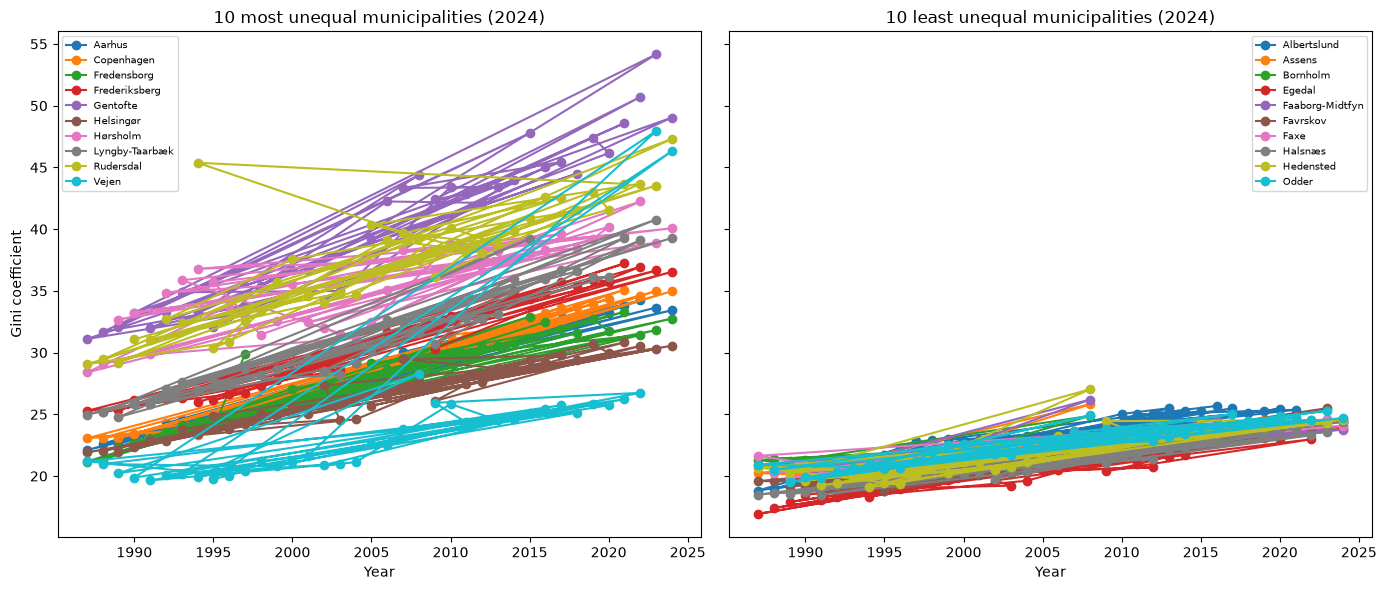

In [26]:
# We now plot the Gini coefficient over time for the 10 most and 10 least unequal municipalities.
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for name, group in sample[sample['KOMMUNEDK'].isin(top10['KOMMUNEDK'])].groupby('KOMMUNEDK'):
    axes[0].plot(group['TID'], group['Gini coefficient'], marker='o', label=name)
axes[0].set_title('10 most unequal municipalities (2024)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Gini coefficient')
axes[0].legend(fontsize=7)

for name, group in sample[sample['KOMMUNEDK'].isin(bottom10['KOMMUNEDK'])].groupby('KOMMUNEDK'):
    axes[1].plot(group['TID'], group['Gini coefficient'], marker='o', label=name)
axes[1].set_title('10 least unequal municipalities (2024)')
axes[1].set_xlabel('Year')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()


As mentioned above, the dataset is a bit clustered, but we can still deduce some things from the plot. 
We see that the Gini coefficient in the least unequal municipalities is steadily rising, but that there are no outliers, and we can say that the Gini coefficient in 2024 is representative of the general tendency across municipalities.
The Gini coefficient in the most unequal municipalities in 2024 however,doesn't have the same steady development. Vejen especially is an outlier in 2024, as the inequality is usually on a much lower level than in 2024. This is likely due to Vejen not being a big municipality and a few rich individuals skewer the data.

The Gini coefficent of the municipalities in 2024 is therefore a measure that should be interpreted carefully, as there can be outliers because we only are observing one year. Apart from Vejen, the data is relatively representative of the inequality levels in the municipalities.



### 1.3.3 Largest and smallest change in the Gini coefficient

We can use the dataset from the above assignment to find the municipalities that have the largest and smallest change in the Gini coefficient

In [27]:
# We compare the Gini coefficient in the first year and the last year across municipalities, and see which municipalities have had the biggest and smallest changes in inequality over time.
# The first year in the dataset is 1987, and the last year is 2024. We will calculate the change in Gini coefficient for each municipality between these two years.

params={
    'table': 'IFOR41',
    'format': 'BULK',
    'lang':'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code':'TID', 'values': ['1987','2024']},
        {'code':'KOMMUNEDK', 'values': ['*']},       
    ]
}
Gini_change = IFOR41.get_data(params=params)
Gini_change = Gini_change.rename(columns={'INDHOLD': 'Gini coefficient'})

# We want to split the data into two separate dataframes, one for 1987 and one for 2024
Gini_1987 = Gini_change[Gini_change['TID'] == 1987][['KOMMUNEDK', 'Gini coefficient']].rename(columns={'Gini coefficient': 'Gini_1987'})
Gini_2024 = Gini_change[Gini_change['TID'] == 2024][['KOMMUNEDK', 'Gini coefficient']].rename(columns={'Gini coefficient': 'Gini_2024'})

# We convert the Gini coefficients to numeric types
Gini_1987['Gini_1987'] = pd.to_numeric(Gini_1987['Gini_1987'], errors='coerce')
Gini_2024['Gini_2024'] = pd.to_numeric(Gini_2024['Gini_2024'], errors='coerce')
# We merge the two dataframes on 'KOMMUNEDK' to calculate the change in Gini coefficient for each municipality
Gini_merged = pd.merge(Gini_1987, Gini_2024, on='KOMMUNEDK')
Gini_merged['Change in Gini'] = Gini_merged['Gini_2024'] - Gini_merged['Gini_1987']
# We sort the dataframe by 'Change in Gini' to find the municipalities with the biggest and smallest changes in inequality over time
Gini_merged_sorted = Gini_merged.sort_values('Change in Gini', ascending=False).reset_index(drop=True)

# We now create two separate dataframes, one for the top 10 municipalities with the biggest increase in Gini coefficient, and one for the bottom 10 municipalities with the biggest decrease in Gini coefficient.
Gini_change_top=Gini_merged_sorted.head(10)
Gini_change_bottom=Gini_merged_sorted.tail(10)
display(Gini_change_top)
display(Gini_change_bottom)
# We merge the two dataframes to create a combined dataframe for plotting
Gini_change_combined = pd.concat([Gini_change_top, Gini_change_bottom])






,KOMMUNEDK,Gini_1987,Gini_2024,Change in Gini
0,Vejen,21.20,46.32,25.12
1,Rudersdal,29.05,47.31,18.26
2,Gentofte,31.10,49.04,17.94
3,Lyngby-Taarbæk,24.97,39.28,14.31
4,Copenhagen,23.05,34.97,11.92
5,Hørsholm,28.39,40.07,11.68
6,Fredensborg,21.17,32.76,11.59
7,Aarhus,22.10,33.43,11.33
8,Frederiksberg,25.28,36.54,11.26
9,Vallensbæk,15.90,26.70,10.80


,KOMMUNEDK,Gini_1987,Gini_2024,Change in Gini
89,Odder,20.93,24.70,3.77
90,Mariagerfjord,22.31,25.98,3.67
91,Stevns,21.35,24.77,3.42
92,Sorø,22.24,25.16,2.92
93,Faaborg-Midtfyn,20.88,23.77,2.89
94,Bornholm,21.31,24.03,2.72
95,Læsø,22.81,25.41,2.60
96,Faxe,21.64,24.09,2.45
97,Ærø,24.63,26.98,2.35
98,Fanø,25.67,26.34,0.67


We want to illustrate it, as we did in the previous task. Keep in mind that Vejen is an outlier and shouldn't be accounted for. 

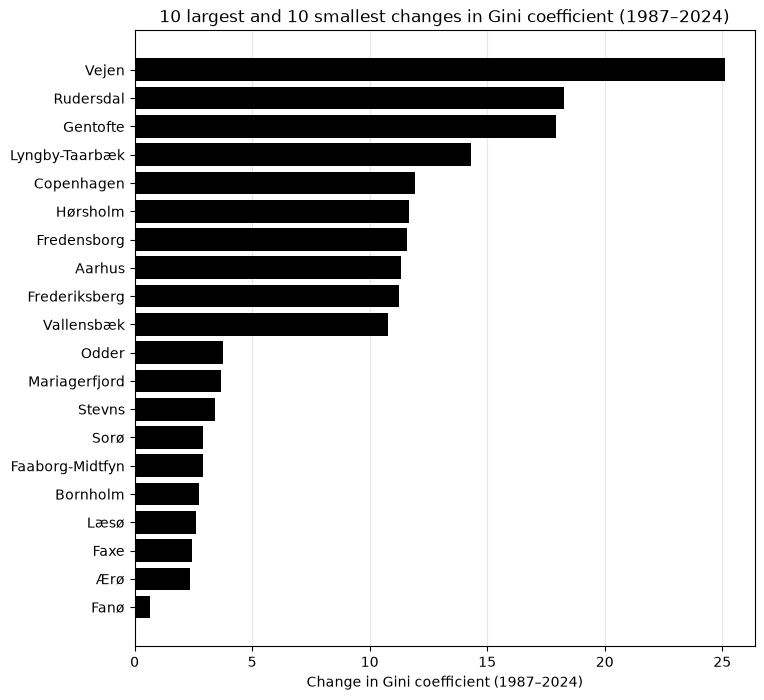

In [28]:
# We plot the difference in Gini coefficient between 1987 and 2024 for all municipalities
# We merge 
# We make a horizontal bar plot to visualize the change in Gini coefficient for each municipality, sorted by the change in Gini coefficient.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
Gini_change_combined['Change in Gini'] = pd.to_numeric(Gini_change_combined['Change in Gini'], errors='coerce')

municipalities_only = Gini_change_combined[Gini_change_combined['KOMMUNEDK'] != 'All Denmark']
municipalities_only = municipalities_only.sort_values('Change in Gini', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(municipalities_only['KOMMUNEDK'], municipalities_only['Change in Gini'], color='black')
ax.set_xlabel('Change in Gini coefficient (1987–2024)')
ax.set_title('10 largest and 10 smallest changes in Gini coefficient (1987–2024)')
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)
ax.invert_yaxis()
plt.show()




The biggest change in the Gini coefficient is in Rudersdal Kommune, where the change is 18.26, and the smallest change is in Fanø Kommune with 0.67. There is quite a big difference in thesse changes, so the inequality has been developing differently in the municipalities across time

## 1.4 Extension

We want to compare the development in the Gini coefficient with the total amount of cash benefit recipients.
We import our data from KY045 - the data only dates back to 2016, so we will compare this period of this time. 

We will look at the same municipalities as the above task, even though they might now be the municipalities with the biggest change in Gini during in 2016-2024 - it just makes it easier to compare


In [29]:
KY045=DstApi('KY045')
KY045.tablesummary(language='en')

Table KY045: Cash benefits (full-time) by region, visitation and time
Last update: 2026-06-19T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,OMRÅDE,117,000,All Denmark,997,Abroad,False
1,VISITATION,6,TOT,"Visitations, total",9,Not stated,False
2,Tid,10,2016,2016,2025,2025,True


We want to clean the dataset, so we have the relevant measures. We want all the municipalities, and the respective amount of cash benifit recipients in the time period

In [30]:
# We clean the dataset, so we only have the relevant columns and rows for our analysis.
# We only want the municipalities, years and visitations, total values.
params={
    'table': 'KY045',
    'format': 'BULK',
    'lang':'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['*']},
        {'code':'VISITATION', 'values': ['TOT']},
        {'code':'Tid', 'values': ['*']},       
    ]
}

CBR=IFOR41.get_data(params=params)

display(CBR.head(10))



,OMRÅDE,VISITATION,TID,INDHOLD
0,Gladsaxe,"Visitations, total",2020,1091
1,Herlev,"Visitations, total",2020,498
2,All Denmark,"Visitations, total",2016,161538
3,Province Københavns omegn,"Visitations, total",2016,13950
4,Province Bornholm,"Visitations, total",2016,1111
5,Province Vest- og Sydsjælland,"Visitations, total",2016,19705
6,Province Sydjylland,"Visitations, total",2016,20511
7,Region Midtjylland,"Visitations, total",2016,32810
8,Region Hovedstaden,"Visitations, total",2016,50000
9,Province Østjylland,"Visitations, total",2016,23028


In [31]:
# We want to remove the rows that are not municipalities, so we only have the municipalities in our dataset.
exclude_pattern = r'Region|Province|All Denmark'
CBR = CBR[~CBR['OMRÅDE'].str.contains(exclude_pattern, case=False, na=False)]
display(CBR.head(10))


,OMRÅDE,VISITATION,TID,INDHOLD
0,Gladsaxe,"Visitations, total",2020,1091
1,Herlev,"Visitations, total",2020,498
10,Copenhagen,"Visitations, total",2016,22288
11,Frederiksberg,"Visitations, total",2016,1938
12,Brøndby,"Visitations, total",2016,1465
13,Gentofte,"Visitations, total",2016,1126
14,Glostrup,"Visitations, total",2016,673
15,Albertslund,"Visitations, total",2016,1035
16,Høje-Taastrup,"Visitations, total",2016,1634
17,Rødovre,"Visitations, total",2016,1170


We now do the same thing we did in 1.3, where we create two datasets and merge them together where we subtract to find the change in the number of cash benifit recipients

In [32]:
# We change 'OMRÅDE' to 'KOMMUNEDK' to match the other datasets,'Tid' to 'TID' and 'Indhold' to 'RECIPIENTS' to match the other datasets.
CBR=CBR.rename(columns={'OMRÅDE': 'KOMMUNEDK', 'Tid': 'TID', 'INDHOLD': 'RECIPIENTS'})
# We create the new dataset CBR_change by mergin CBR_2016 and CBR_2024, and calculating the change in visitations for each municipality between these two years.
CBR_2016 = CBR[CBR['TID'] == 2016][['KOMMUNEDK', 'RECIPIENTS']].rename(columns={'RECIPIENTS': 'CBR_2016'})
CBR_2024 = CBR[CBR['TID'] == 2024][['KOMMUNEDK', 'RECIPIENTS']].rename(columns={'RECIPIENTS': 'CBR_2024'})

# We merge the two dataframes on 'KOMMUNEDK' to calculate the change in visitations for each municipality
CBR_change = pd.merge(CBR_2016, CBR_2024, on='KOMMUNEDK')
CBR_change['Change in CBR'] =CBR_change['CBR_2024'] -CBR_change['CBR_2016']

display(CBR_change.head(5))

,KOMMUNEDK,CBR_2016,CBR_2024,Change in CBR
0,Copenhagen,22288,9365,-12923
1,Frederiksberg,1938,1209,-729
2,Brøndby,1465,800,-665
3,Gentofte,1126,549,-577
4,Glostrup,673,347,-326


We now want to correct our data from 1.3, as we have to compare the same time period

In [33]:
# Changing the timeperiod to 2016-2024 for the Gini coefficient, so we can compare the change in Gini coefficient with the change in visitations for each municipality.
# We do this by reusing the code and replacing 1987 with 2016
params={
    'table': 'IFOR41',
    'format': 'BULK',
    'lang':'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code':'TID', 'values': ['2016','2024']},
        {'code':'KOMMUNEDK', 'values': ['*']},       
    ]
}
Gini_change_1624 = IFOR41.get_data(params=params)
Gini_change_1624 = Gini_change_1624.rename(columns={'INDHOLD': 'Gini coefficient'})

# We split the data into two separate dataframes, one for 2016 and one for 2024
Gini_2016_1624 = Gini_change_1624[Gini_change_1624['TID'] == 2016][['KOMMUNEDK', 'Gini coefficient']].rename(columns={'Gini coefficient': 'Gini_2016'})
Gini_2024_1624 = Gini_change_1624[Gini_change_1624['TID'] == 2024][['KOMMUNEDK', 'Gini coefficient']].rename(columns={'Gini coefficient': 'Gini_2024'})

# We convert the Gini coefficients to numeric types
Gini_2016_1624['Gini_2016'] = pd.to_numeric(Gini_2016_1624['Gini_2016'], errors='coerce')
Gini_2024_1624['Gini_2024'] = pd.to_numeric(Gini_2024_1624['Gini_2024'], errors='coerce')

# We merge the two dataframes on 'KOMMUNEDK' to calculate the change in Gini coefficient for each municipality
Gini_merged_1624 = pd.merge(Gini_2016_1624, Gini_2024_1624, on='KOMMUNEDK')
Gini_merged_1624['Change in Gini'] = Gini_merged_1624['Gini_2024'] - Gini_merged_1624['Gini_2016']

# We want the same municipalities as the 1987-2024 selection, so we filter instead of re-ranking by the 2016-2024 change
Gini_selected = Gini_merged_1624[Gini_merged_1624['KOMMUNEDK'].isin(municipalities_only['KOMMUNEDK'])]
display(Gini_selected)

# We also filter CBR_change to the same municipalities, so we can compare the change in Gini coefficient with the change in visitations for each municipality.
CBR_selected = CBR_change[CBR_change['KOMMUNEDK'].isin(municipalities_only['KOMMUNEDK'])]
display(CBR_selected)

,KOMMUNEDK,Gini_2016,Gini_2024,Change in Gini
1,Copenhagen,33.24,34.97,1.73
2,Frederiksberg,34.85,36.54,1.69
6,Gentofte,45.02,49.04,4.02
13,Lyngby-Taarbæk,35.96,39.28,3.32
17,Vallensbæk,24.64,26.70,2.06
20,Fredensborg,32.48,32.76,0.28
23,Hørsholm,38.27,40.07,1.80
24,Rudersdal,42.63,47.31,4.68
35,Faxe,23.78,24.09,0.31
39,Stevns,24.18,24.77,0.59


,KOMMUNEDK,CBR_2016,CBR_2024,Change in CBR
0,Copenhagen,22288,9365,-12923
1,Frederiksberg,1938,1209,-729
3,Gentofte,1126,549,-577
10,Fredensborg,816,361,-455
12,Rudersdal,779,362,-417
20,Sorø,754,413,-341
23,Bornholm,1111,404,-707
28,Ærø,112,34,-78
31,Fanø,69,16,-53
32,Vejen,1082,564,-518


We now have our the necessary data to make our plot, and see if the devolopment moves in the direction. We will have change in Gini as our y-axis and change in CBR as our x-axis

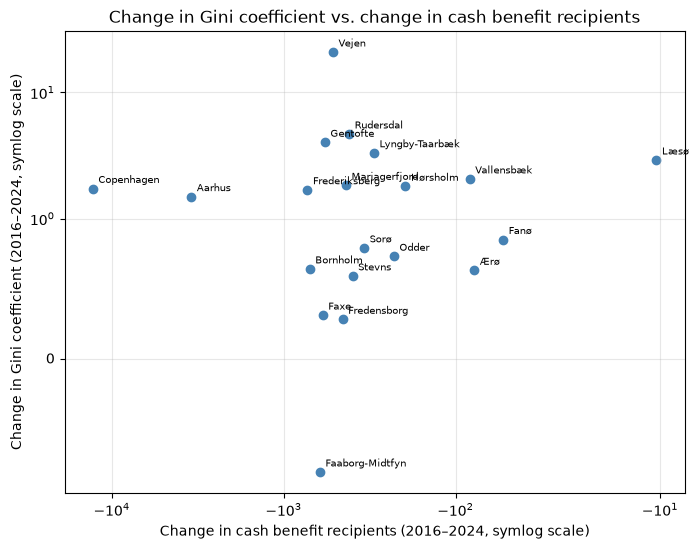

Correlation between change in Gini coefficient and change in cash benefit recipients: 0.0450


In [34]:
# We plot the change in Gini coefficient against the change in cash benefit recipients for each municipality, to see if there is a relationship between the two.
plot_data = pd.merge(
    Gini_selected[['KOMMUNEDK', 'Change in Gini']],
    CBR_selected[['KOMMUNEDK', 'Change in CBR']],
    on='KOMMUNEDK'
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_data['Change in CBR'], plot_data['Change in Gini'], color='steelblue')

for _, row in plot_data.iterrows():
    ax.annotate(row['KOMMUNEDK'], (row['Change in CBR'], row['Change in Gini']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')

# Copenhagen, Aarhus (Change in CBR) and Vejen (Change in Gini) are much larger in magnitude
# than the rest, so we use a symmetric log scale to compress the extremes without hiding
# the sign or losing the points near zero.
ax.set_xscale('symlog', linthresh=50)
ax.set_yscale('symlog', linthresh=1)

ax.set_xlabel('Change in cash benefit recipients (2016–2024, symlog scale)')
ax.set_ylabel('Change in Gini coefficient (2016–2024, symlog scale)')
ax.set_title('Change in Gini coefficient vs. change in cash benefit recipients')
ax.grid(alpha=0.3)
plt.show()

correlation = plot_data['Change in Gini'].corr(plot_data['Change in CBR'])
print(f"Correlation between change in Gini coefficient and change in cash benefit recipients: {correlation:.4f}")

The correlation between cash benifit recipients and the Gini coefficient across municipalities is almost non-existent, at only 0.045

In [35]:
%load_ext autoreload
%autoreload 2

# 2.1 Simulating the income distribution
Here we define the model in a seperate module (Egen_model.py) and gradually print out the variables and function,  as we define them, to make sure they actually works and to make it easier to understand for Python beginners.

### 2.1.1 Variables
Here we define the varibles as given in the assignment and print them out to show that they were correctly defined.

In [36]:
import Egen_model
par = Egen_model.setup()
print(par)

{'N': 50000, 'p_e': (0.4, 0.35, 0.25), 'S_e': (1, 3, 5), 'h_e0': (1.0, 1.2, 1.55), 'delta_e': (0.01, 0.02, 0.03), 'lambda_': 0.6, 'sigma': 0.05, 'delta': 0.06, 'sigma_psi': 0.1, 'y_SU': 0.45, 'rho': 0.6, 'y_floor': 0.35, 'T': 47}


### 2.1.2 Empty arrays
Here we create the empty arrays, which later will be needed to make the gradual simulations for each period. They are again printed to verify they have the right dimensions.

In [37]:
import importlib
importlib.reload(Egen_model)  # reload the module to get the latest changes

par = Egen_model.setup()
sim = Egen_model.allocate(par)

print(sim['human_capital'].shape)  # Printing the shape of the human capital array it should be (50000, 47)
print(sim['education'].shape)      # Printing the shape of the education array it should be (50000,)

print(sim['human_capital'])  # Printing the human capital array it should give an array with 47 elements for each person

(50000, 47)
(50000,)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### 2.1.3 Drawing education level
We draw random numbers either 0,1 or 2, each correlating to an education length _short, medium or long_ in an array with the right amounts of individuals (50,000). The probabilities are loaded by "p=par['p_e']" in the Egen_model module which is a vector with the correct propabilities from the assignment.

In [38]:
import numpy as np

par = Egen_model.setup()
sim = Egen_model.allocate(par)

rng = np.random.default_rng(2026)
Egen_model.draw_education(par, sim, rng)

# tjek at andelene passer med p_e = (0.40, 0.35, 0.25)
andele = np.bincount(sim['education']) / par['N']       # Beregner andele af hver uddannelsestype, så den kan printes og vi kan checke den.
print(np.round(andele, 3)) # Printing as f-string with 3 decimal places for better readability

[0.403 0.352 0.246]


We verify that the simulated shares of education length fit the shares given in the assignment.  
From the assignment we have 
$$
e_i \in \{short, medium, long\} = \text{each with the propabilities (0.40, 0.35, 0.25)}
$$
We compare:
$$
\begin{array}{c|c}
 & \text{Assignment} & \text{Own model} \\
\hline
\text{Propabilities} \space (p_e) &  (0.40, 0.35, 0.25) & (0.403, 0.352, 0.246)
\end{array}
$$

Thereby we conclude that we have correctly specified the model.

### 2.1.4 Timeloop and simulating model
Here we make the timeloop which actually simulates the model one period at a time. 

In [39]:
par = Egen_model.setup()
sim = Egen_model.allocate(par)

rng = np.random.default_rng(2026)
Egen_model.draw_education(par, sim, rng)
Egen_model.simulate(par, sim, rng) # Now also simulates the labor market, human capital and income after education (see Egen_model.py)

# Check: a person with long education (education=2) should have income=0.45 at t=0..4
# This is because they get the SU, while in education.
i = np.where(sim['education'] == 2)[0][0]
print(sim['income'][i, 0:5])

# Check: a person with short education (education=0) has finished school after t=0,
# so at t=1 they have just entered the labor market as unemployed with no job history yet.
# That means income at t=1 should be exactly the floor y_floor=0.35 (this is deterministic -
# the randomness in job finding only affects what happens from t=2 onwards).
i = np.where(sim['education'] == 0)[0][0]
print(sim['income'][i, 0], sim['income'][i, 1], '(forventer: 0.45 0.35)')

t=0: 50000 personer er stadig under uddannelse
t=1: 29870 personer er stadig under uddannelse
t=2: 29870 personer er stadig under uddannelse
t=3: 12294 personer er stadig under uddannelse
t=4: 12294 personer er stadig under uddannelse
t=5: 0 personer er stadig under uddannelse
[0.45 0.45 0.45 0.45 0.45]
0.45 0.35 (forventer: 0.45 0.35)


## 2.2 Simulate the income distribution

### 2.2.1 Checking that the simulation is correct
We already checked in 2.1.3 that the simulated education shares match $p_e$. The assignment also asks us to check that the unemployment rate settles at its steady-state value $\sigma/(\sigma+\lambda)$.

We only look at people who are done with their education (i.e. who are "active" in the labor market), and only in the last 10 years of the simulation, so we are sure the employment Markov chain has had time to settle down.

In [40]:
# creates an (N,T) array that is True if the person is "active" (i.e., done with with their education) in year t 
S_e = np.array(par['S_e'])
years_in_education = S_e[sim['education']]
ages_t = np.arange(par['T'])
active = years_in_education[:, None] <= ages_t[None, :]   # (N,T) boolean

# only looks at the last 10 years, and only at those who are active there
active_last = active[:, -10:]
employed_last = sim['employed'][:, -10:]

andel_ledige = 1 - employed_last[active_last].mean()
steady_state = par['sigma'] / (par['sigma'] + par['lambda_'])

print(f'Share of unemployed in the simulation (last 10 years): {andel_ledige:.4f}')
print(f'Steady state sigma / (sigma + lambda):       {steady_state:.4f}')

Share of unemployed in the simulation (last 10 years): 0.0768
Steady state sigma / (sigma + lambda):       0.0769


The two steady state-values are very close to eachother, so we conclude that the model is correctly specified.

### 2.2.2 Mean and percentiles of income over the life cycle
We now plot how income develops over the life cycle (age 18-64), both on average and for a few percentiles (10th, 50th/median and 90th). This is done for *all* individuals pooled together (including the years they are still in education).

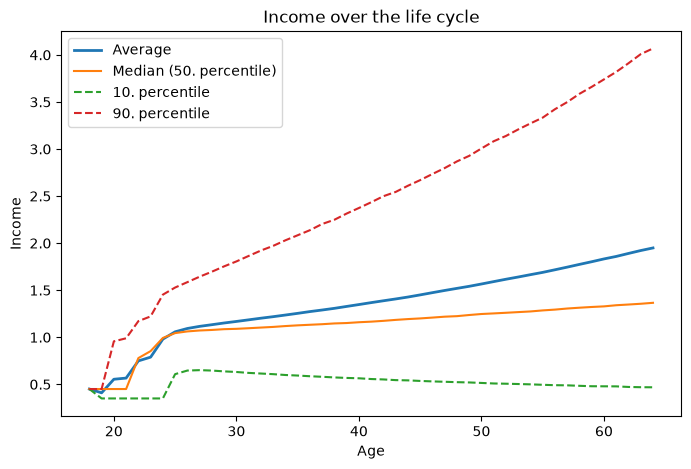

In [41]:
import matplotlib.pyplot as plt

alder = np.arange(18, 18 + par['T'])   # x-akse: alder 18 til 64

# np.percentile with axis=0 takes the percentile over people (N), separately for each age (T)
gns_indkomst = sim['income'].mean(axis=0)
p10 = np.percentile(sim['income'], 10, axis=0)
p50 = np.percentile(sim['income'], 50, axis=0)
p90 = np.percentile(sim['income'], 90, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alder, gns_indkomst, label='Average', linewidth=2)
ax.plot(alder, p50, label='Median (50. percentile)')
ax.plot(alder, p10, label='10. percentile', linestyle='--')
ax.plot(alder, p90, label='90. percentile', linestyle='--')
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_title('Income over the life cycle')
ax.legend()
plt.show()

Income is flat and low while people are in education (this is the SU-part), then jumps up once people enter the labor market. After that, the mean and median both grow steadily as human capital builds up, and the gap between the 10th and 90th percentile grows wider over the life cycle - differences in education and in luck (job loss, human capital shocks) compound over time.

### 2.2.3 Histogram of the income distribution at ages 25, 35, 45 and 60
We now look at the *shape* of the income distribution at four different ages, by making a histogram of income across all N individuals at each of those ages.

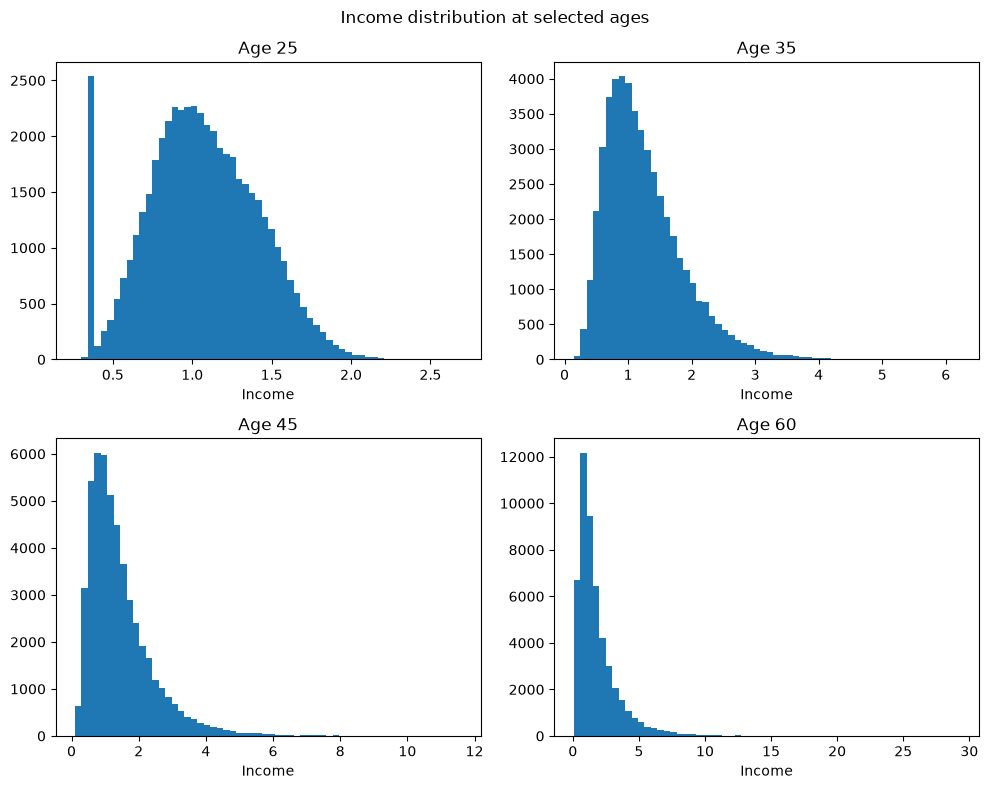

In [42]:
udvalgte_aldre = [25, 35, 45, 60]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()   # Makes it easier to loop over the 4 subplots


for ax, alder_i in zip(axes, udvalgte_aldre):
    t = alder_i - 18   # converts everything to t-index (age 18 = t=0)
    ax.hist(sim['income'][:, t], bins=60)
    ax.set_title(f'Age {alder_i}')
    ax.set_xlabel('Income')

fig.suptitle('Income distribution at selected ages')
fig.tight_layout()
plt.show()

At age 25 most people are still close together (they have only just entered the labor market), but there is already a small group with low income (those still in education or unlucky enough to be unemployed). That is, the bin at $income = 0.35$ that can appear as an outlier for age 25, is actually the people who just finished their educations and still haven't got a job. With age, the chance of never having a job drops, which reduces the amount of individuals in this bin.

At age 35, 45 and 60 the distribution becomes wider and more spread out to the right: the main 'bulk' of employed people moves to higher income as human capital builds up, while a small left tail of people with a long unemployment history stays behind. So the distribution goes from fairly tight and symmetric to wide and left heavy (right-skewed) as the individuals grow old.

## 2.3 Compute the Gini coefficient
We have written our own `gini_lorenz()`-function in `Egen_model.py`. It calculates the area iteratively of the trapezoid between each individual's percentile 'placement' in the population and 'placement' in the income-dsitribution. That is, it calculates the area between the last and the next individuals in the dsitribution, to take the sum and find the area under the Lorenz curve. First we find the ratio between cummulated income (placement) and the total income (placement) for each individual. It will be used beneath:

$$
x_i = \frac{i}{n}, \qquad
L_i = \frac{\sum_{k=1}^{i} y_{(k)}}{\sum_{k=1}^{n} y_{(k)}}, \qquad
L_0 = 0, \quad i = 0, 1, \dots, n
$$



Where $y_{(1)} \le y_{(2)} \le \dots \le y_{(n)}$ are the incomes sorted in rising order.  
The area under the Lorenz-curve is calculated by the 'trapezoid-method'. Which simply multiplies the width between datapoints by average heidth:

$$
B = \sum_{i=1}^{n} (x_i - x_{i-1}) \cdot \frac{L_i + L_{i-1}}{2}
  = \frac{1}{2n}\sum_{i=1}^{n} \left( L_i + L_{i-1} \right)
$$

And since the area beneath the 45-degrees line is $A + B = \tfrac{1}{2}$, we can get the gini-coefficient as:  

$$
G = \frac{A}{A+B} = 1 - 2B
$$

### 2.3.1 Testing our own gini-function
Before trusting the function on our simulated data, we test it on two cases where we know the answer:
- A uniform distribution on $[0,1]$ should give a Gini coefficient of exactly $1/3$, as stated in the asignment.
- A lognormal distribution where the underlying normal has std. $s$ should give $2\Phi(\tfrac{s}{\sqrt{2}}) - 1$, which is also stated in the assignment.

In [43]:
from scipy.stats import norm

rng_test = np.random.default_rng(42)

# uniform[0,1] - should give ca. 1/3
y_uniform = rng_test.random(1_000_000)
print('Gini for uniform[0,1]:', round(Egen_model.gini_lorenz(y_uniform), 4), '  (facit: 0.3333)')

# lognormal with std s in the log - should give 2*Phi(s/sqrt(2)) - 1
s = 0.5
y_lognormal = rng_test.lognormal(0, s, size=1_000_000)
facit = 2 * norm.cdf(s / np.sqrt(2)) - 1
print('Gini for lognormal:      ', round(Egen_model.gini_lorenz(y_lognormal), 4), '  (facit:', round(facit, 4), ')')

Gini for uniform[0,1]: 0.3333   (facit: 0.3333)
Gini for lognormal:       0.2762   (facit: 0.2763 )


Both numbers match the known answer closely, so we conclude taht the function on our own simulated data is correclty specified.

### 2.3.2 Gini coefficient for the full sample and the Lorenz curve
We now pool all individuals and all ages together into one big vector of incomes, and compute the Gini coefficient for that. We also plot the Lorenz curve: for each point $p$ on the x-axis (share of the population, sorted from poorest to richest), the y-axis shows the share of total income that this poorest $p$ share of the population holds. The 45-degree line is what we would see under perfect equality.

Gini-coefficient, every individual and every age: 0.3699


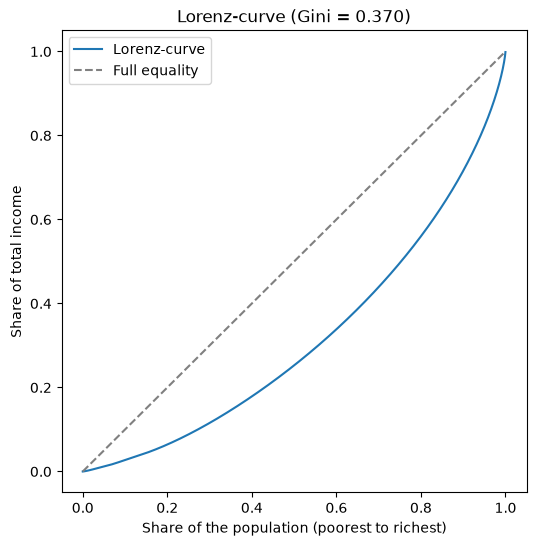

In [44]:
# "flatten" turns our (N,T) array into one long 1d vector with all incomes
# for all people and all years, mixed together
alle_indkomster = sim['income'].flatten()

gini_pooled = Egen_model.gini_lorenz(alle_indkomster)
print('Gini-coefficient, every individual and every age:', round(gini_pooled, 4))

# Lorenz curve: sort the incomes, and see how large a share of total
# income the poorest p% "own"
y_sorteret = np.sort(alle_indkomster)
kumuleret_indkomst = np.cumsum(y_sorteret) / np.sum(y_sorteret)   # share / ratio of total income
andel_befolkning = np.arange(1, len(y_sorteret) + 1) / len(y_sorteret)   # share / ratio of total population

# we've got a lot of points (N*T), so we only plot every 200th point to make it faster
steps = 200

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(andel_befolkning[::steps], kumuleret_indkomst[::steps], label='Lorenz-curve')
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Full equality')
ax.set_xlabel('Share of the population (poorest to richest)')
ax.set_ylabel('Share of total income')
ax.set_title(f'Lorenz-curve (Gini = {gini_pooled:.3f})')
ax.legend()
plt.show()

### 2.3.3 Gini coefficient by age, compared to the pooled Gini
We now compute the Gini coefficient separately for each age (i.e. for each column in `sim['income']`), and compare it to the pooled number from above.

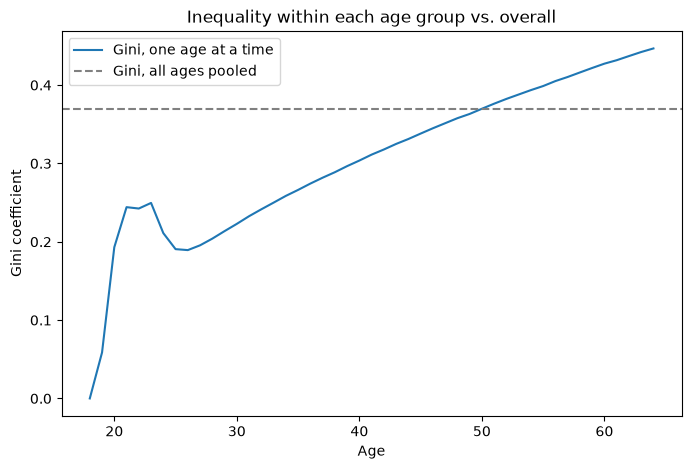

Gennemsnitlig gini inden for en aldersgruppe: 0.3042
Gini når alle aldre samles (pooled):          0.3699


In [45]:
gini_per_alder = np.zeros(par['T'])

for t in range(par['T']):   # simple loop, since we only have 47 ages - no need to vectorize this
    gini_per_alder[t] = Egen_model.gini_lorenz(sim['income'][:, t])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alder, gini_per_alder, label='Gini, one age at a time')
ax.axhline(gini_pooled, color='grey', linestyle='--', label='Gini, all ages pooled')
ax.set_xlabel('Age')
ax.set_ylabel('Gini coefficient')
ax.set_title('Inequality within each age group vs. overall')
ax.legend()
plt.show()

print('Gennemsnitlig gini inden for en aldersgruppe:', round(gini_per_alder.mean(), 4))
print('Gini når alle aldre samles (pooled):         ', round(gini_pooled, 4))

The pooled Gini coefficient is higher than the Gini coefficient within a single age group. This makes sense because when we pool all ages together, we not only measure inequality *between* people of the same age, but also the systematic income-differences *between* age groups. That extra age-income gap adds to measured inequality once everyone is pooled together.

## 2.4 What drives inequality?

### 2.4.1 Running the simulations
We now turn off one mechanism at a time, and see how much the Gini coefficient changes compared to the baseline. Since `par` is just a dictionary, we can turn off a mechanism by overriding a few of its values before we simulate again:

- No educational differences: everyone gets the same years of education, the same starting human capital and the same growth rate (we use the "medium" education's values for everyone).
- No human capital shocks: `sigma_psi = 0` (the shock $\psi$ is always exactly 1).
- No depreciation while unemployed: `delta = 0`.
- No unemployment: `sigma = 0` and `lambda_ = 1`, so once you have a job you never lose it, and you find a new one immediately if you ever become unemployed (the only unemployment left is the single year right after finishing school).

We use the same seed (2026) for every scenario, so the only thing that differs between them is the mechanism we turn off.

In [46]:
def koer_scenarie(overrides, alder_til_check=45):
    """ runs the model with parameters overridden by 'overrides', and returns gini pooled + gini at one age """

    par_s = Egen_model.setup()
    par_s.update(overrides)   # overrides the parameters we want to change in this scenario

    sim_s = Egen_model.allocate(par_s)
    rng_s = np.random.default_rng(2026)   # same seed in all scenarios, so it's only the mechanism that changes
    Egen_model.draw_education(par_s, sim_s, rng_s)
    Egen_model.simulate(par_s, sim_s, rng_s, verbose=False)   # verbose=False, so we don't get overwhelmed with print statements

    t = alder_til_check - 18
    gini_alle = Egen_model.gini_lorenz(sim_s['income'].flatten())
    gini_alder = Egen_model.gini_lorenz(sim_s['income'][:, t])

    return gini_alle, gini_alder


scenarier = {
    'Baseline':                     {},
    'No educational differences':   {'S_e': (3, 3, 3), 'h_e0': (1.20, 1.20, 1.20), 'delta_e': (0.02, 0.02, 0.02)},
    'No shocks to human capital':  {'sigma_psi': 0.0},
    'No depreciation as unemployed': {'delta': 0.0},
    'No unemployment':               {'sigma': 0.0, 'lambda_': 1.0},
}

print(f'{"Scenario":32s}{"Gini (all ages)":>14s}{"Gini (age 45)":>18s}')
for navn, overrides in scenarier.items():
    gini_alle, gini_45 = koer_scenarie(overrides)
    print(f'{navn:32s}{gini_alle:14.4f}{gini_45:18.4f}')

Scenario                        Gini (all ages)     Gini (age 45)
Baseline                                0.3699            0.3381
No educational differences              0.3276            0.2912
No shocks to human capital              0.2711            0.2113
No depreciation as unemployed           0.3768            0.3265
No unemployment                         0.3735            0.3234


### 2.4.2 Which mechanism matters the most?  
Turning off the human capital shocks ($\sigma_\psi = 0$) reduces the Gini coefficient by far by the most (pooled: 0.370 to 0.271, age 45: 0.338 to 0.211)  random luck in human capital growth is the main driver of income inequality in this model. Turning off educational differences also matters quite a bit (pooled: 0.370 to 0.328). Turning off unemployment itself barely changes anything, because the steadystate unemployment rate is fairly low (around 8%) to begin with.

## 2.5 Extension: more risk
Our extension is on top of the risk that is already in the model (human capital shocks and unemployment risk), we add more extra wage risk for people who are in a job. Even with the exact same human capital, two people's actual pay can differ a bit from year to year, for instance because of luck in job conversations or other random noise. We model this as an extra mean-one lognormal shock $\xi_{i,t}$ so that income while employed becomes $y_{i,t} = h_{i,t} \cdot \xi_{i,t}$ instead of just $h_{i,t}$. This is a simple shock, but could prove an insightful addition.

We modified our model so that it is built onti this into `Egen_model.simulate()` as the optional `sigma_xi` argument. We now turn it on and compare to the baseline.

Average income,  baseline vs. expanded: 1.3445 1.3478
Gini (all ages),             baseline vs. expanded: 0.3699 0.41
Gini (age 45),         baseline vs. expanded: 0.3381 0.3835


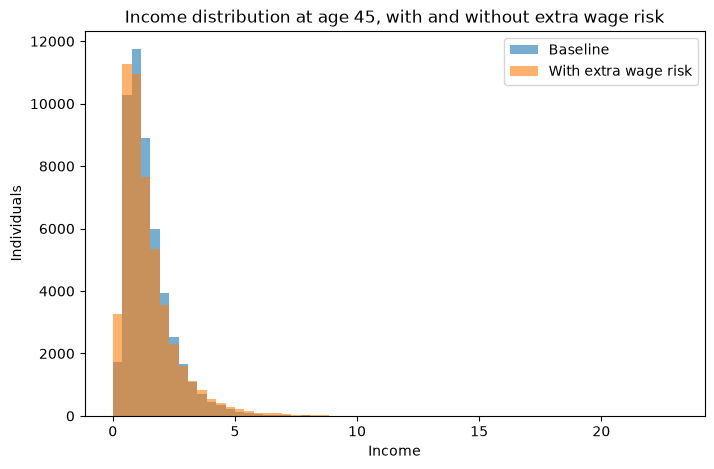

In [47]:
# base line(same as before, sigma_xi=0 is default)
par_base = Egen_model.setup()
sim_base = Egen_model.allocate(par_base)
rng_base = np.random.default_rng(2026)
Egen_model.draw_education(par_base, sim_base, rng_base)
Egen_model.simulate(par_base, sim_base, rng_base, verbose=False)

# expanded model, with extra wage risk sigma_xi=0.15
par_ext = Egen_model.setup()
sim_ext = Egen_model.allocate(par_ext)
rng_ext = np.random.default_rng(2026)   # samme seed som baseline
Egen_model.draw_education(par_ext, sim_ext, rng_ext)
Egen_model.simulate(par_ext, sim_ext, rng_ext, sigma_xi=0.35, verbose=False)

print('Average income,  baseline vs. expanded:', round(sim_base['income'].mean(), 4), round(sim_ext['income'].mean(), 4))
print('Gini (all ages),             baseline vs. expanded:', round(Egen_model.gini_lorenz(sim_base['income'].flatten()), 4), round(Egen_model.gini_lorenz(sim_ext['income'].flatten()), 4))

t = 45 - 18
print('Gini (age 45),         baseline vs. expanded:', round(Egen_model.gini_lorenz(sim_base['income'][:, t]), 4), round(Egen_model.gini_lorenz(sim_ext['income'][:, t]), 4))

# histrogram-comparison at age 45
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, max(sim_base['income'][:, t].max(), sim_ext['income'][:, t].max()), 61) # Give the same bins to both histograms, so they are comparable
ax.hist(sim_base['income'][:, t], bins=bins, alpha=0.6, label='Baseline')
ax.hist(sim_ext['income'][:, t], bins=bins, alpha=0.6, label='With extra wage risk')
ax.set_xlabel('Income')
ax.set_ylabel('Individuals')
ax.set_title('Income distribution at age 45, with and without extra wage risk')
ax.legend()
plt.show()

The extra wage risk shock doesn't change the distribution of the income for the age group 45 years old a lot. This is as expected as the shock has mean one. It changes the Gini significantly less than turning off shocks to human capital. It does however increase inequality as the standard deviation of income rises in a given period, thereby widening the distribution, which can be seen as the yellow bins increase to the left and to the right of the baseline example.  
  
We should add that we put the wage shock deviation to $\sigma_{\xi}=0.35$ which Claude reckons might be a bit high, compared to real life. But it accentuated the difference between the baseline scenario and our scenario, which is the important point.